# Employee Data Analysis Project

This project analyzes an employee dataset consisting of 458 rows and 9 columns. 
The objective is to perform data preprocessing, analysis, and visualization to 
derive meaningful insights about employee distribution, roles, age groups, salary 
expenditure, and relationships between variables.

Tools used: Python, Pandas, NumPy, Matplotlib, Seaborn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df= pd.read_excel("ABC Company.xlsx")
df


,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,2023-02-06 00:00:00,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,2023-06-06 00:00:00,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,2023-05-06 00:00:00,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,2023-05-06 00:00:00,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,2023-10-06 00:00:00,231,NaN,5000000.0
...,...,...,...,...,...,...,...,...,...
453,Shelvin Mack,Utah Jazz,8,PG,26,2023-03-06 00:00:00,203,Butler,2433333.0
454,Raul Neto,Utah Jazz,25,PG,24,2023-01-06 00:00:00,179,NaN,900000.0
455,Tibor Pleiss,Utah Jazz,21,C,26,2023-03-07 00:00:00,256,NaN,2900000.0
456,Jeff Withey,Utah Jazz,24,C,26,7-0,231,Kansas,947276.0


# Understanding the Data

In [3]:
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458 entries, 0 to 457
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      458 non-null    object 
 1   Team      458 non-null    object 
 2   Number    458 non-null    int64  
 3   Position  458 non-null    object 
 4   Age       458 non-null    int64  
 5   Height    458 non-null    object 
 6   Weight    458 non-null    int64  
 7   College   374 non-null    object 
 8   Salary    447 non-null    float64
dtypes: float64(1), int64(3), object(5)
memory usage: 32.3+ KB


Index(['Name', 'Team', 'Number', 'Position', 'Age', 'Height', 'Weight',
       'College', 'Salary'],
      dtype='object')

* The dataset contains employee details such as Name, Team, Position, Age, Height, Weight, College, and Salary.

In [4]:
df.describe()

,Number,Age,Weight,Salary
count,458.000000,458.000000,458.000000,4.470000e+02
mean,17.713974,26.934498,221.543668,4.833970e+06
std,15.966837,4.400128,26.343200,5.226620e+06
min,0.000000,19.000000,161.000000,3.088800e+04
25%,5.000000,24.000000,200.000000,1.025210e+06
50%,13.000000,26.000000,220.000000,2.836186e+06
75%,25.000000,30.000000,240.000000,6.500000e+06
max,99.000000,40.000000,307.000000,2.500000e+07


In [5]:
df.isnull().sum()
# The dataset contains 458 rows and 9 columns with some missing values in Salary and College.

Name         0
Team         0
Number       0
Position     0
Age          0
Height       0
Weight       0
College     84
Salary      11
dtype: int64

# Preprocessing

In [6]:
# Missing values in the Salary column were handled by replacing them with the mean salary of the dataset to maintain data consistency and avoid loss of records
# Missing values in the College column were replaced with "Unknown"
# since it is a categorical feature and not critical for analysis.
# Data cleaning is an essential step in data analysis as it ensures the accuracy,  consistency, and reliability of the dataset.
# Clean data leads to more accurate analysis, meaningful insights, and better decision-making.
df["Salary"] = df["Salary"].fillna(df["Salary"].mean())
df["College"] = df["College"].fillna("UnKnown")
df.head(5)

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,2023-02-06 00:00:00,180,Texas,7.730337e+06
1,Jae Crowder,Boston Celtics,99,SF,25,2023-06-06 00:00:00,235,Marquette,6.796117e+06
2,John Holland,Boston Celtics,30,SG,27,2023-05-06 00:00:00,205,Boston University,4.833970e+06
3,R.J. Hunter,Boston Celtics,28,SG,22,2023-05-06 00:00:00,185,Georgia State,1.148640e+06
4,Jonas Jerebko,Boston Celtics,8,PF,29,2023-10-06 00:00:00,231,UnKnown,5.000000e+06


In [7]:
# Replacing data in 'Height' column with randon numbers between 150 and 180
df["Height"]= np.random.randint(150,180, size=len(df))
print("After updating height:")
df

After updating height:


,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,171,180,Texas,7.730337e+06
1,Jae Crowder,Boston Celtics,99,SF,25,165,235,Marquette,6.796117e+06
2,John Holland,Boston Celtics,30,SG,27,156,205,Boston University,4.833970e+06
3,R.J. Hunter,Boston Celtics,28,SG,22,171,185,Georgia State,1.148640e+06
4,Jonas Jerebko,Boston Celtics,8,PF,29,170,231,UnKnown,5.000000e+06
...,...,...,...,...,...,...,...,...,...
453,Shelvin Mack,Utah Jazz,8,PG,26,168,203,Butler,2.433333e+06
454,Raul Neto,Utah Jazz,25,PG,24,173,179,UnKnown,9.000000e+05
455,Tibor Pleiss,Utah Jazz,21,C,26,150,256,UnKnown,2.900000e+06
456,Jeff Withey,Utah Jazz,24,C,26,171,231,Kansas,9.472760e+05


In [8]:
# check duplictes
int(df.duplicated().sum())

0

In [9]:
# No duplicate records found in the dataset

# Data Analysis & Visualization


**1. Distribution of employees across each team and calculation the percentage split relative to the total number of employees.**

In [10]:
team_distribution= df['Team'].value_counts()
print('Team distribution:\n', team_distribution)
team_percentage= (team_distribution/len(df))*100
print('\nTeam percentage:\n', team_percentage)

Team distribution:
 Team
New Orleans Pelicans      19
Memphis Grizzlies         18
Utah Jazz                 16
New York Knicks           16
Milwaukee Bucks           16
Brooklyn Nets             15
Portland Trail Blazers    15
Oklahoma City Thunder     15
Denver Nuggets            15
Washington Wizards        15
Miami Heat                15
Charlotte Hornets         15
Atlanta Hawks             15
San Antonio Spurs         15
Houston Rockets           15
Boston Celtics            15
Indiana Pacers            15
Detroit Pistons           15
Cleveland Cavaliers       15
Chicago Bulls             15
Sacramento Kings          15
Phoenix Suns              15
Los Angeles Lakers        15
Los Angeles Clippers      15
Golden State Warriors     15
Toronto Raptors           15
Philadelphia 76ers        15
Dallas Mavericks          15
Orlando Magic             14
Minnesota Timberwolves    14
Name: count, dtype: int64

Team percentage:
 Team
New Orleans Pelicans      4.148472
Memphis Grizzlies   

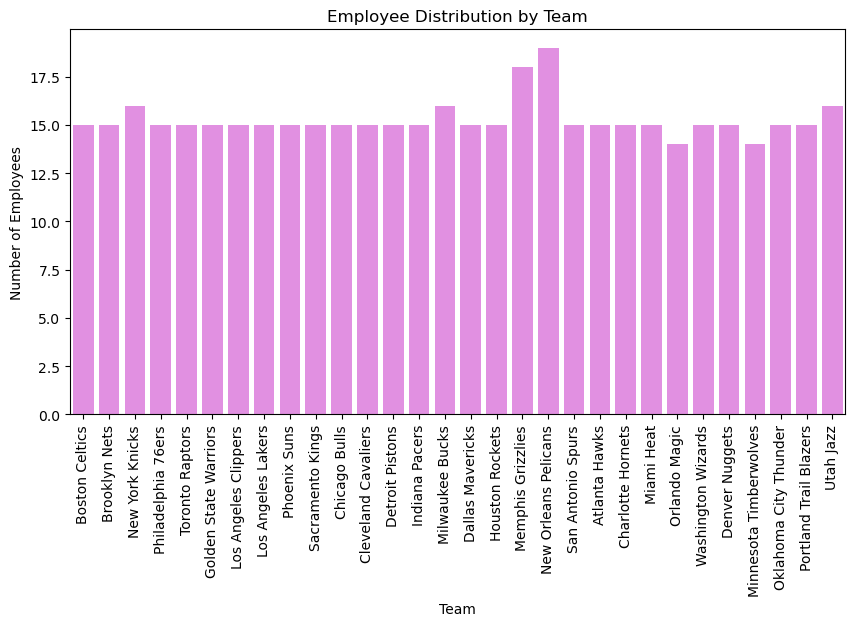

In [11]:
# Visualization
# Countplot is used to visualize categorical distribution 
plt.figure(figsize=(10,5))
sns.countplot(x= 'Team', data=df, color= 'violet')
plt.xticks(rotation=90)
plt.title('Employee Distribution by Team')
plt.xlabel('Team')
plt.ylabel('Number of Employees')
plt.show()

**Data story:**
*  The graph shows that employees are fairly evenly distributed across all teams,  with most teams having around 14–16 employees. A few teams like the New Orleans Pelicans and Memphis Grizzlies have slightly higher counts, while some teams have slightly fewer. 
* Overall, the distribution indicates a balanced workforce across teams with minor variations.

**2. Segregation of employees based on their positions within company**

In [12]:
position_counts = df['Position'].value_counts()
position_counts

Position
SG    102
PF    100
PG     92
SF     85
C      79
Name: count, dtype: int64

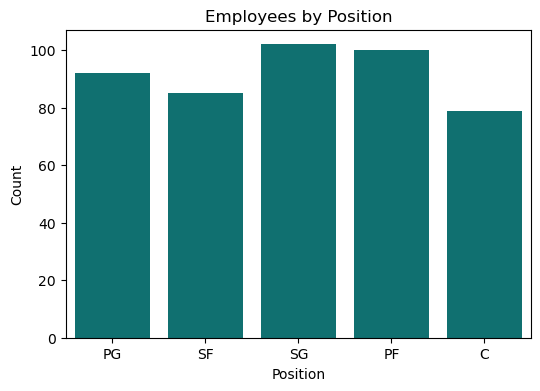

In [13]:
# Visualization
# Countplot helps in comparing catogorical values
plt.figure(figsize=(6,4))
sns.countplot(x='Position', data=df, color='teal')
plt.title('Employees by Position')
plt.xlabel('Position')
plt.ylabel('Count')
plt.show()

**Data story:**
* The graph shows the distribution of employees across different positions.
* SG and PF positions have the highest number of employees while position C have the lowest.
* This indicates a slightly higher demand for SG and PF  in the organization

**3. Predominant age group among employees**

In [14]:
df['Age'].unique()


array([25, 27, 22, 29, 21, 24, 20, 26, 28, 32, 23, 30, 33, 34, 37, 36, 31,
       38, 39, 19, 35, 40])

In [15]:
df['Age_Group'] = pd.cut(df['Age'], bins=[20,25,30,35,40], labels=['20-25', '25-30', '30-35', '35-40'])
df['Age_Group'].value_counts()
# Most employees belong to the 20–30 age range

Age_Group
20-25    179
25-30    167
30-35     68
35-40     23
Name: count, dtype: int64

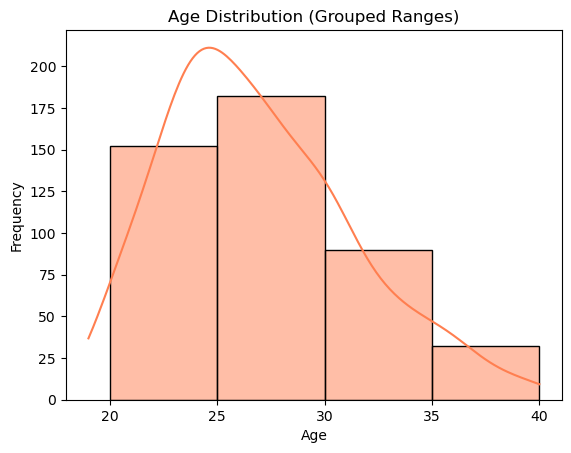

In [16]:
# Visualization
# Histogram is used to show the distribution of employees based on age

sns.histplot(df['Age'], bins=[20,25,30,35,40], color='coral', edgecolor='black', kde=True)
plt.title("Age Distribution (Grouped Ranges)")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

**Data story:**
* The data indicates that most employees fall within the 20-20 age range, with the highest concentration in the early to mid-20s.
* The number of employees decreases as age increases, showing a prodominantly young workforce.

**4. Team and position having highest salary expenditure**

In [17]:
team_salary = df.groupby('Team')['Salary'].sum().sort_values(ascending=False)
position_salary = df.groupby('Position')['Salary'].sum().sort_values(ascending=False)
print('Salary by Team:\n',team_salary)
print('\nSalary by Position:\n',position_salary)

Salary by Team:
 Team
Cleveland Cavaliers       1.118227e+08
Memphis Grizzlies         9.588676e+07
Los Angeles Clippers      9.485464e+07
Oklahoma City Thunder     9.376530e+07
Miami Heat                9.218361e+07
Golden State Warriors     8.886900e+07
Chicago Bulls             8.678338e+07
San Antonio Spurs         8.444273e+07
New Orleans Pelicans      8.275077e+07
Charlotte Hornets         7.834092e+07
Washington Wizards        7.632864e+07
Houston Rockets           7.528302e+07
New York Knicks           7.330390e+07
Atlanta Hawks             7.290295e+07
Los Angeles Lakers        7.177043e+07
Sacramento Kings          7.168367e+07
Dallas Mavericks          7.119873e+07
Toronto Raptors           7.111761e+07
Milwaukee Bucks           6.960352e+07
Detroit Pistons           6.716826e+07
Indiana Pacers            6.675183e+07
Denver Nuggets            6.495590e+07
Minnesota Timberwolves    6.454367e+07
Utah Jazz                 6.400737e+07
Phoenix Suns              6.344514e+07
Bos

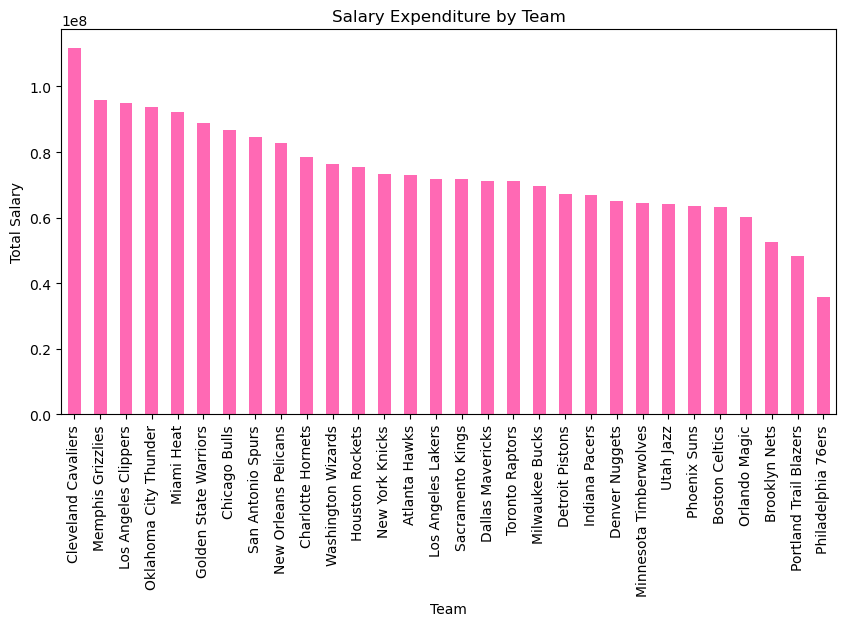

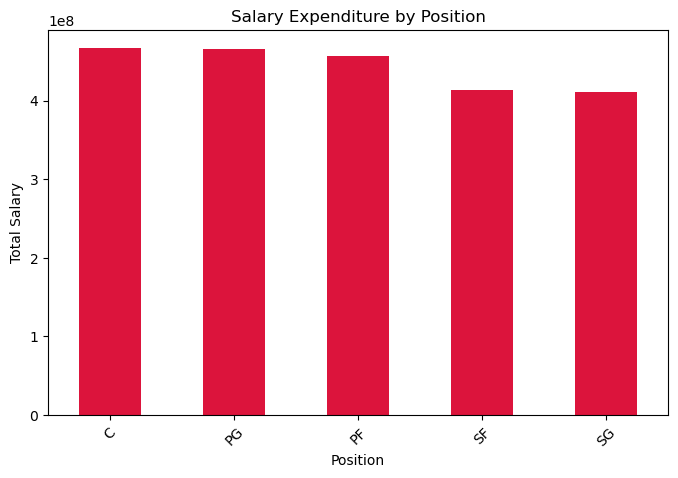

In [18]:
# Visualization
# Bar chart is used for comparison across categories.

team_salary.plot(kind='bar', figsize=(10,5), color='hotpink')
plt.title('Salary Expenditure by Team')
plt.xlabel('Team')
plt.ylabel('Total Salary')
plt.show()

position_salary.plot(kind='bar', figsize=(8,5), color='crimson')
plt.title('Salary Expenditure by Position')
plt.xlabel('Position')
plt.xticks(rotation=45)
plt.ylabel('Total Salary')
plt.show()

**Data story:**

**Analysis by Team:**
* The Cleveland Cavaliers have the highest salary expenditure, exceeding $100 million, 
* while teams like the Philadelphia 76ers have significantly lower spending. 
* This shows that salary allocation varies across teams, with some teams investing more heavily in their workforce.
  
**Analysis by Position:**
* Among positions, 'C' has the highest total salary expenditure, followed by 'PG', while 'SF' and 'SG' have comparatively lower expenditure.
* This suggests that certain roles are given higher financial priority within the organization.


**5. Correlation between age and salary**

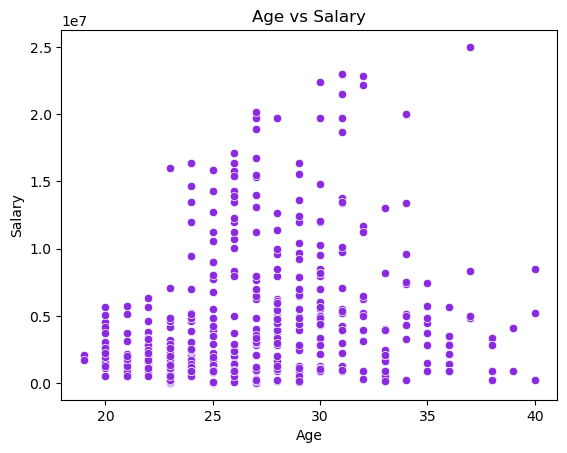

Correlation: 0.21116954917686373


In [19]:
sns.scatterplot(x='Age', y='Salary', data=df, color='blueviolet')
plt.title("Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")
plt.show()
print("Correlation:", df['Age'].corr(df['Salary']))

**Data story:**
* The correlation coefficient (~0.21) shows a weak positive relationship between age and salary. 
* While there is a slight tendency for salary to increase with age, the wide spread of data points 
* indicates that age alone does not determine salary. This suggests that other factors such as role and performance also influence salary.

**Final Insights**
* Employee distribution across teams is relatively balanced with minor variations.
* Certain positions such as SG and PF have higher representation in the workforce.
* The majority of employees fall within the 20–30 age group, indicating a young workforce.
* Salary expenditure is concentrated in specific teams like Cleveland Cavaliers and roles like C and PG.
* There is a weak positive correlation between age and salary, suggesting that experience has a slight influence on earnings.